<a href="https://colab.research.google.com/github/yusuf3662/softito/blob/main/21.9.2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
df_test = pd.read_csv("/content/sample_data/california_housing_test.csv")
df_train = pd.read_csv("/content/sample_data/california_housing_train.csv")
df_test.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-122.05,37.37,27.0,3885.0,661.0,1537.0,606.0,6.6085,344700.0
1,-118.30,34.26,43.0,1510.0,310.0,809.0,277.0,3.5990,176500.0
2,-117.81,33.78,27.0,3589.0,507.0,1484.0,495.0,5.7934,270500.0
3,-118.36,33.82,28.0,67.0,15.0,49.0,11.0,6.1359,330000.0
4,-119.67,36.33,19.0,1241.0,244.0,850.0,237.0,2.9375,81700.0


In [12]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
import pandas as pd


X_train = df_train.drop('median_house_value', axis=1)
y_train = df_train['median_house_value']


X_test = df_test.drop('median_house_value', axis=1)
y_test = df_test['median_house_value']


models = {
    'Linear Regression': make_pipeline(StandardScaler(), LinearRegression()),
    'Ridge Regression': make_pipeline(StandardScaler(), Ridge(alpha=1.0)),
    'Lasso Regression': make_pipeline(StandardScaler(), Lasso(alpha=1.0, max_iter=2000))
}

results = {}


for name, model in models.items():
    print(f"{name} modeli...")
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    mae = mean_absolute_error(y_test, predictions)
    r2 = r2_score(y_test, predictions)
    mse = mean_squared_error(y_test, predictions)
    results[name] = {'MAE': mae, 'MSE': mse, 'R2 Score': r2}
    print(f"{name} MAE: {mae:.2f}, MSE: {mse:.2f}, R2 Score: {r2:.2f}")


comparison_df = pd.DataFrame.from_dict(results, orient='index')
comparison_df.index.name = 'Model'

display(comparison_df.sort_values(by='MAE'))


Linear Regression modeli...
Linear Regression MAE: 50352.23, MSE: 4867205486.93, R2 Score: 0.62
Ridge Regression modeli...
Ridge Regression MAE: 50351.45, MSE: 4867111148.75, R2 Score: 0.62
Lasso Regression modeli...
Lasso Regression MAE: 50352.30, MSE: 4867187514.36, R2 Score: 0.62


,MAE,MSE,R2 Score
Model,,,
Ridge Regression,50351.447229,4.867111e+09,0.619513
Linear Regression,50352.228258,4.867205e+09,0.619506
Lasso Regression,50352.300277,4.867188e+09,0.619507


/tmp/ipykernel_1047/1463644851.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


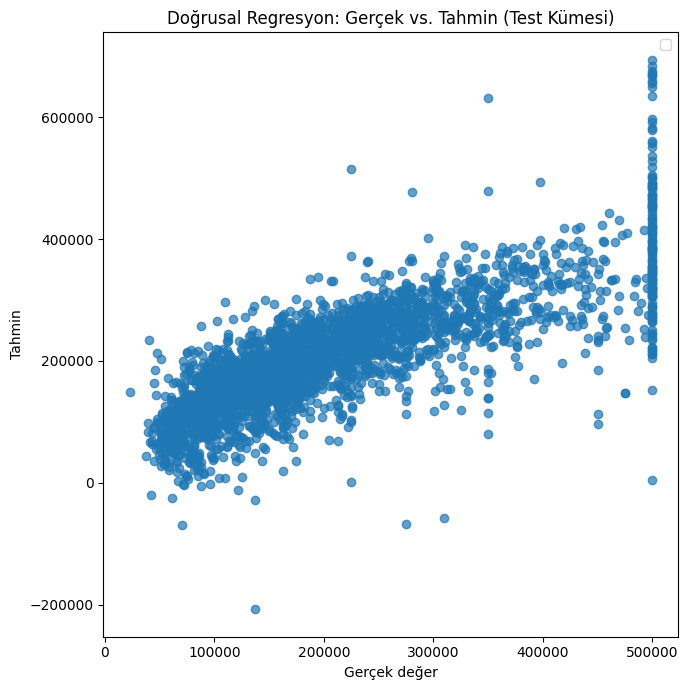

In [14]:
import matplotlib.pyplot as plt

linear_model_trained = models['Linear Regression']
predictions_linear = linear_model_trained.predict(X_test)

plt.figure(figsize=(7, 7))
plt.scatter(y_test, predictions_linear, alpha=0.7)

plt.xlabel("Gerçek değer")
plt.ylabel("Tahmin")
plt.title("Doğrusal Regresyon: Gerçek vs. Tahmin (Test Kümesi)")
plt.legend()
plt.tight_layout()
plt.show()

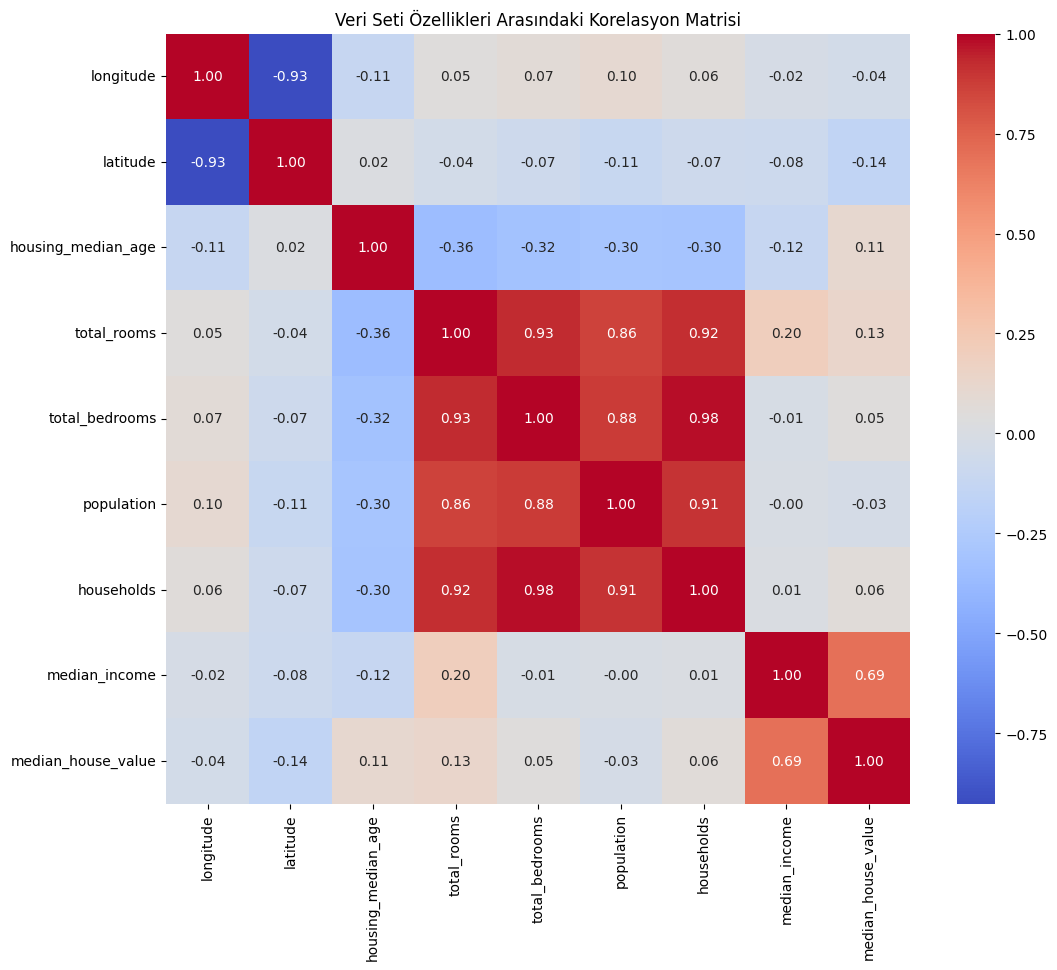

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

correlation_matrix = df_train.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Korelasyon Matrisi')
plt.show()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           3000 non-null   float64
 1   latitude            3000 non-null   float64
 2   housing_median_age  3000 non-null   float64
 3   total_rooms         3000 non-null   float64
 4   total_bedrooms      3000 non-null   float64
 5   population          3000 non-null   float64
 6   households          3000 non-null   float64
 7   median_income       3000 non-null   float64
 8   median_house_value  3000 non-null   float64
dtypes: float64(9)
memory usage: 211.1 KB
